# MNIST Overfitting and Regularization Analysis

## Introduction
For this task, I set out to investigate how and why neural networks overfit on training data, and what practical steps can be taken to mitigate this behavior. I chose the well-known MNIST handwritten digit dataset and selected a fully-connected Multi-Layer Perceptron (MLP) as the primary architecture.

A fully-connected MLP contains no convolutional layers and has none of the spatial inductive biases (such as weight sharing or translation equivariance) that naturally resist overfitting. This makes it the ideal architecture family for demonstrating and analyzing overfitting clearly and holidays on both loss and accuracy curves. Everything below uses the MLP architecture family throughout, including the baseline, so that the only variable that changes between experiments is capacity and training protocol (not the architecture family itself).

The study is organized into three experiments, all using the full 70,000-image MNIST pool with an identical train/validation/test split:
1. **Baseline:** A compact, appropriately sized MLP trained without any tricks on the full training set. This confirms that MNIST itself is not difficult to generalize on when model capacity is well matched.
2. **Part A:** A deliberately over-parameterized MLP (same input data, same split) trained without any regularization. The goal is to observe overfitting that occurs purely from architectural excess, with nothing about the data or split changed.
3. **Part B:** The identical over-parameterized architecture from Part A (with not one parameter changed) trained on the same data, but now with data augmentation, weight decay, early stopping, and a learning rate scheduler added to the training protocol. This demonstrates how training-time regularization alone can recover generalization without touching the architecture.

All three experiments are compared side-by-side through training curves, test set evaluations, confusion matrices, and per-class accuracy charts. Training progress for every model is displayed live with `tqdm` progress bars showing per-batch loss and running accuracy.


## 1. Importing Libraries and Device Selection

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, ConcatDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import time
import copy
import itertools
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import seaborn as sns

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Global plot styling -- applied to every figure in the notebook
sns.set_theme(style="whitegrid", palette="deep")
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10.5,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "grid.alpha": 0.35,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
})


COLOR_UNREG_TRAIN    = "#1F77B4"   # blue
COLOR_UNREG_VAL      = "#D62728"   # red
COLOR_BASELINE_TRAIN = "#9467BD"   # purple
COLOR_BASELINE_VAL   = "#9467BD"   # purple (same shade, distinguished by linestyle in the plot)
COLOR_REG_TRAIN      = "#2CA02C"   # green
COLOR_REG_VAL        = "#2CA02C"   # green (same shade, distinguished by linestyle in the plot)



Device: cuda
PyTorch Version: 2.11.0+cu128
GPU: Tesla T4


## 2. Dataset Split and Preprocessing

To construct the dataset splits, I merged all 70,000 MNIST samples (60,000 training + 10,000 test) into a single pool. From this combined pool, I performed a stratified split to divide the data into:
- 70% for training (49,000 images)
- 15% for validation (10,500 images)
- 15% for testing (10,500 images)

The stratified approach guarantees that each of the three subsets maintains an identical proportion of the 10 digit classes, preventing any class imbalance from skewing the results. All images are normalized using the standard MNIST channel mean (0.1307) and standard deviation (0.3081).

Additionally, to study overfitting on a smaller dataset, we extract a stratified 8,000-image subset from the training set. This smaller dataset pool mimics scenarios where data is scarce relative to model capacity, leading to rapid overfitting.

In [2]:
# Preprocessing transform
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download dataset parts and merge them
train_dataset_std = datasets.MNIST(root='./data', train=True, download=True, transform=basic_transform)
test_dataset_std = datasets.MNIST(root='./data', train=False, download=True, transform=basic_transform)
full_dataset_std = ConcatDataset([train_dataset_std, test_dataset_std])

# Extract labels for stratified split
all_targets = torch.cat([train_dataset_std.targets, test_dataset_std.targets]).numpy()

# Perform stratified splits (70% train, 30% val+test)
indices = np.arange(len(all_targets))
train_idx, val_test_idx = train_test_split(
    indices, test_size=0.3, stratify=all_targets, random_state=42
)

# Split val+test into validation (15% total) and testing (15% total)
val_test_targets = all_targets[val_test_idx]
val_idx, test_idx = train_test_split(
    val_test_idx, test_size=0.5, stratify=val_test_targets, random_state=42
)

train_set = Subset(full_dataset_std, train_idx)
val_set   = Subset(full_dataset_std, val_idx)
test_set  = Subset(full_dataset_std, test_idx)



BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=256,        shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256,        shuffle=False, num_workers=0)

print(f"Training set:        {len(train_set)} images")
print(f"Validation set:      {len(val_set)} images")
print(f"Test set:            {len(test_set)} images")
print(f"Image shape:         {full_dataset_std[0][0].shape} (C, H, W)")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Training set:        49000 images
Validation set:      10500 images
Test set:            10500 images
Image shape:         torch.Size([1, 28, 28]) (C, H, W)


## 3. Visualizing the Data

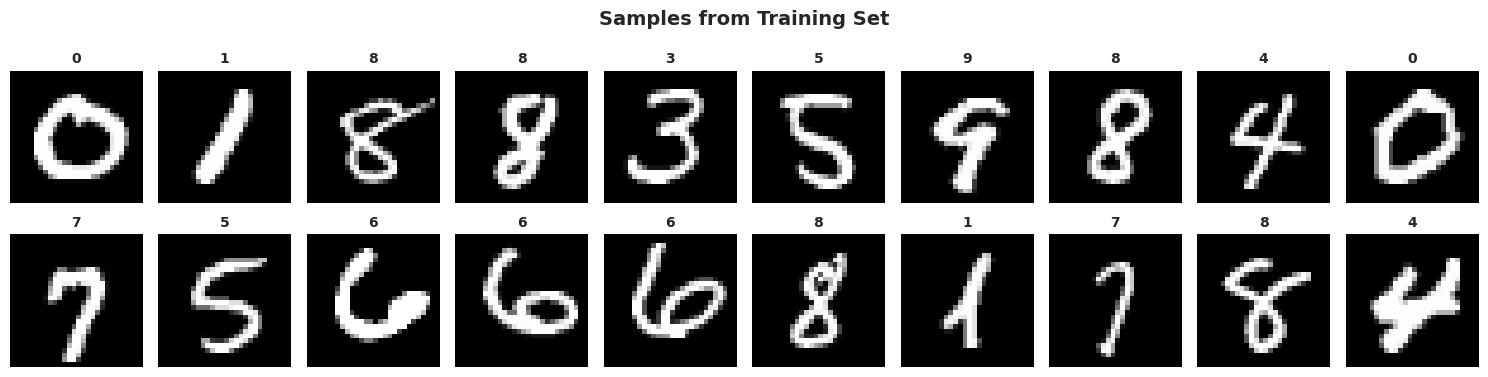

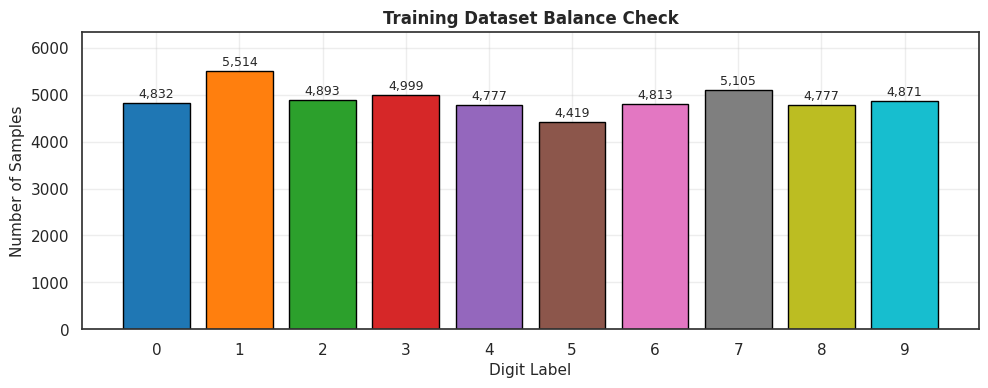

In [3]:
# Plot some sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    ax = axes[i // 10, i % 10]
    image, label = train_set[i]
    raw_img = (image.squeeze() * 0.3081 + 0.1307).numpy()
    ax.imshow(raw_img, cmap='gray')
    ax.set_title(str(label), fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("Samples from Training Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot the distribution of classes in train split
train_labels = all_targets[train_idx]
classes, frequency = np.unique(train_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(classes, frequency, color=plt.cm.tab10(np.arange(10)), edgecolor='black')
ax.set_xlabel("Digit Label")
ax.set_ylabel("Number of Samples")
ax.set_title("Training Dataset Balance Check", fontsize=12, fontweight='bold')
ax.set_xticks(range(10))
ax.set_ylim(0, max(frequency) * 1.15)
for bar, val in zip(bars, frequency):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f"{val:,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Helper Functions for Training and Evaluation

In [4]:
def run_single_epoch(model, loader, loss_fn, opt, dev, epoch_idx, total_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    progress_bar = tqdm(loader, desc=f"Epoch {epoch_idx+1:02d}/{total_epochs}", leave=False)
    for inputs, targets in progress_bar:
         inputs, targets = inputs.to(dev), targets.to(dev)
         opt.zero_grad()
         outputs = model(inputs)
         loss = loss_fn(outputs, targets)
         loss.backward()
         opt.step()
         running_loss += loss.item() * inputs.size(0)
         _, preds = outputs.max(1)
         correct_preds += preds.eq(targets).sum().item()
         total_samples += targets.size(0)
         current_acc = 100.0 * correct_preds / total_samples
         progress_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{current_acc:.2f}%")
    return running_loss / total_samples, 100.0 * correct_preds / total_samples

def evaluate_performance(model, loader, loss_fn, dev):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(dev), targets.to(dev)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct_preds += preds.eq(targets).sum().item()
            total_samples += targets.size(0)
    return running_loss / total_samples, 100.0 * correct_preds / total_samples

def train_network(model, train_loader, val_loader, loss_fn, opt, epochs, dev,
                  scheduler=None, early_stop_patience=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'learning_rates': []}
    best_val_loss = float('inf')
    best_weights = None
    no_improvement_epochs = 0
    start_time = time.time()
    for epoch in range(epochs):
        epoch_start = time.time()
        t_loss, t_acc = run_single_epoch(model, train_loader, loss_fn, opt, dev, epoch, epochs)
        v_loss, v_acc = evaluate_performance(model, val_loader, loss_fn, dev)
        current_lr = opt.param_groups[0]['lr']
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['learning_rates'].append(current_lr)
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(v_loss)
            else:
                scheduler.step()
        epoch_time = time.time() - epoch_start
        print(f"\nEpoch {epoch+1:02d}/{epochs} | Train Loss: {t_loss:.4f} | Train Acc: {t_acc:.2f}% | "
              f"Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}% | LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")
        if early_stop_patience is not None:
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                best_weights = copy.deepcopy(model.state_dict())
                no_improvement_epochs = 0
            else:
                no_improvement_epochs += 1
                if no_improvement_epochs >= early_stop_patience:
                    print(f"\nEarly stopping triggered at epoch {epoch+1}. "
                          f"Best val loss: {best_val_loss:.4f}")
                    model.load_state_dict(best_weights)
                    break
    total_time = time.time() - start_time
    print(f"Training finished in {total_time:.1f} seconds")
    return history

In [5]:
def plot_metrics(history, label_prefix, train_color='#1f77b4', val_color='#d62728'):
    """Plot loss and accuracy curves for a single model's training history,
    with the train/val gap shaded so overfitting (or the lack of it) is
    immediately visible."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], color=train_color, label='Training Loss')
    ax1.plot(epochs, history['val_loss'],   color=val_color,   label='Validation Loss')
    ax1.fill_between(epochs, history['train_loss'], history['val_loss'], alpha=0.12, color=val_color)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f"{label_prefix}: Loss History")
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.4)

    ax2.plot(epochs, history['train_acc'], color=train_color, label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'],   color=val_color,   label='Validation Accuracy')
    ax2.fill_between(epochs, history['train_acc'], history['val_acc'], alpha=0.12, color=val_color)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f"{label_prefix}: Accuracy History")
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f"{label_prefix} -- Training Progress", fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()


    gap = history['train_acc'][-1] - history['val_acc'][-1]
    fig, ax = plt.subplots(figsize=(4.5, 4))
    bars = ax.bar(['Train', 'Val'], [history['train_acc'][-1], history['val_acc'][-1]],
                  color=[train_color, val_color], edgecolor='black', width=0.55)
    for b, v in zip(bars, [history['train_acc'][-1], history['val_acc'][-1]]):
        ax.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.2f}%", ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f"{label_prefix}\nFinal Gap: {gap:.2f}%", fontsize=11, fontweight='bold')
    ax.set_ylim(min(history['val_acc'][-1], history['train_acc'][-1]) - 5, 100.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


## 5. Baseline Model

Before deliberately inducing overfitting, it is important to establish a **baseline** - a small, appropriately sized model. This baseline serves a critical role in the overall analysis: if a properly sized model generalizes cleanly, then any overfitting observed later in Part A can be attributed directly to overparameterization rather than to the dataset, training procedure, or architecture family.

The baseline is a small MLP: the image is flattened to 784 features and passed through a single hidden layer of 64 units, followed by BatchNorm1d (included as standard training practice to keep activations stable, not as a regularizer), ReLU, and a 20% Dropout layer. No weight decay, early stopping, or data augmentation is applied. Using an MLP here - the same architectural family as the Part A/B model in Sections 6-8 - means the only variables that change between this baseline and the deliberately-overfit model are capacity, epoch count, and dropout, not the architecture family itself.

At roughly **1/85th the parameter count** of the Part A/B model (51,018 vs. 4,364,554), this architecture is well matched to 28x28 grayscale digit classification. The baseline model is trained on the full 49,000-image training set for 12 epochs.


In [6]:
class BaselineMLP(nn.Module):

    def __init__(self):
        super(BaselineMLP, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.classifier(x)

model_baseline = BaselineMLP().to(device)
param_count_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)

experimental_param_count = 4364554
print(f"Baseline MLP      - Total parameters: {param_count_baseline:,}")
print(f"ExperimentalMLP   - Total parameters: {experimental_param_count:,}")
print(f"Capacity ratio    - ExperimentalMLP is {experimental_param_count // param_count_baseline}x larger")

Baseline MLP      - Total parameters: 51,018
ExperimentalMLP   - Total parameters: 4,364,554
Capacity ratio    - ExperimentalMLP is 85x larger


In [7]:
loss_criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=0.001, weight_decay=0.0)

BASELINE_EPOCHS = 12

print("Training baseline model...")
history_baseline = train_network(
    model=model_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_criterion,
    opt=optimizer_baseline,
    epochs=BASELINE_EPOCHS,
    dev=device
)

Training baseline model...


Epoch 01/12:   0%|          | 0/766 [00:00<?, ?it/s]


Epoch 01/12 | Train Loss: 0.4348 | Train Acc: 88.94% | Val Loss: 0.2176 | Val Acc: 93.81% | LR: 0.001000 | Time: 17.4s


Epoch 02/12:   0%|          | 0/766 [00:00<?, ?it/s]


Epoch 02/12 | Train Loss: 0.2313 | Train Acc: 93.23% | Val Loss: 0.1709 | Val Acc: 95.01% | LR: 0.001000 | Time: 18.0s


...


Epoch 10/12 | Train Loss: 0.1110 | Train Acc: 96.52% | Val Loss: 0.1036 | Val Acc: 96.91% | LR: 0.001000 | Time: 16.5s


Epoch 11/12:   0%|          | 0/766 [00:00<?, ?it/s]


Epoch 11/12 | Train Loss: 0.1044 | Train Acc: 96.63% | Val Loss: 0.0991 | Val Acc: 97.00% | LR: 0.001000 | Time: 16.5s


Epoch 12/12:   0%|          | 0/766 [00:00<?, ?it/s]


Epoch 12/12 | Train Loss: 0.1004 | Train Acc: 96.81% | Val Loss: 0.0996 | Val Acc: 97.18% | LR: 0.001000 | Time: 17.8s
Training finished in 203.9 seconds


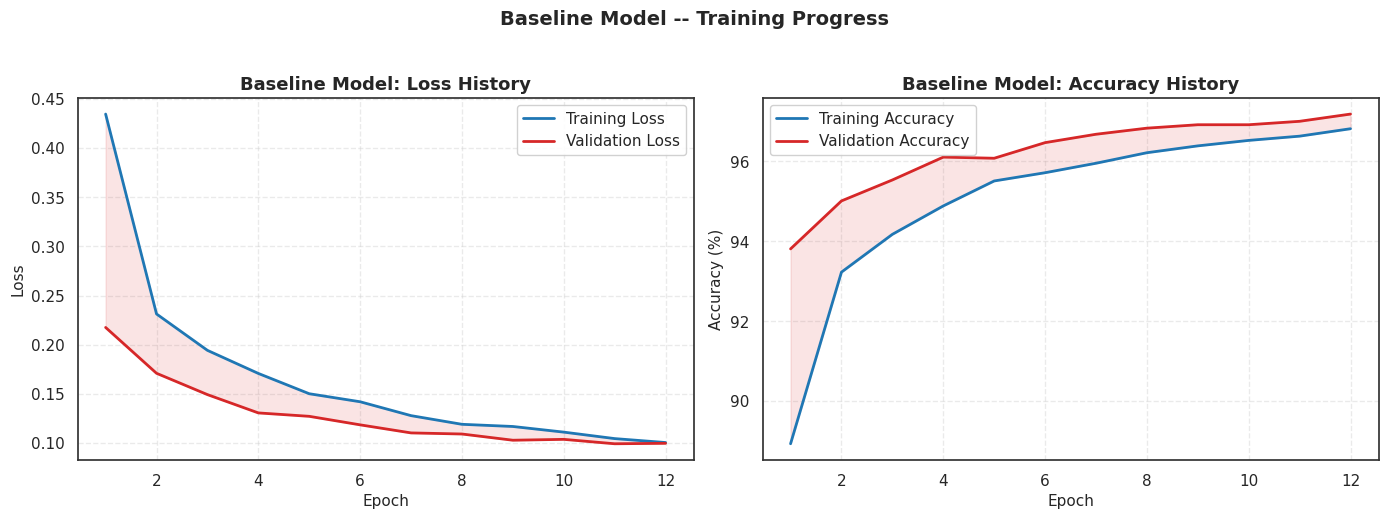

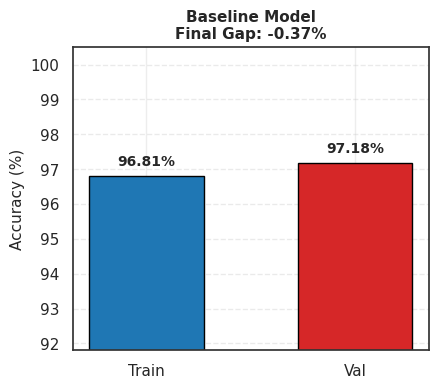

Final Training Accuracy:   96.81%
Final Validation Accuracy: 97.18%
Difference:                -0.37%
Final Training Loss:       0.1004
Final Validation Loss:     0.0996
Loss Ratio (Val / Train):  0.99x


In [8]:
plot_metrics(history_baseline, "Baseline Model", train_color=COLOR_UNREG_TRAIN, val_color=COLOR_UNREG_VAL)

t_acc_baseline  = history_baseline['train_acc'][-1]
v_acc_baseline  = history_baseline['val_acc'][-1]
t_loss_baseline = history_baseline['train_loss'][-1]
v_loss_baseline = history_baseline['val_loss'][-1]

print(f"Final Training Accuracy:   {t_acc_baseline:.2f}%")
print(f"Final Validation Accuracy: {v_acc_baseline:.2f}%")
print(f"Difference:                {t_acc_baseline - v_acc_baseline:.2f}%")
print(f"Final Training Loss:       {t_loss_baseline:.4f}")
print(f"Final Validation Loss:     {v_loss_baseline:.4f}")
print(f"Loss Ratio (Val / Train):  {v_loss_baseline / max(t_loss_baseline, 1e-8):.2f}x")


## 6. Designing the Overfit Model

To study overfitting in a clear, unconstrained setting, we design a massive, fully-connected Multi-Layer Perceptron (MLP) with four hidden layers: the input image is flattened to a 784-dimensional vector and passed through the layers (2048 -> 1024 -> 512 -> 256 -> 10) in the class `ExperimentalMLP`.

An MLP treats every pixel as an independent feature and lacks convolutional spatial priors (such as weight sharing or spatial locality). Because it has no built-in architectural constraints, a high-capacity MLP is free to memorize exact pixel-level patterns specific to the training set. With over **4.36 million trainable parameters** (roughly 85 times the baseline), this model contains excessive capacity for simple 28x28 grayscale digit classification.

No dropout, batch normalization, or any other form of regularization is included in this architecture, since the explicit goal is to observe the model overfitting on the training data.


In [9]:
class ExperimentalMLP(nn.Module):

    def __init__(self):
        super(ExperimentalMLP, self).__init__()
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(x)

test_model = ExperimentalMLP().to(device)
param_count = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Total parameters: {param_count:,}")
print(f"Parameters per training sample: {param_count / len(train_set):.2f}")
del test_model

Total parameters: 4,364,554
Parameters per training sample: 89.07


## 7. Part A: Training Without Any Regularization

In this experiment, I trained the over-parameterized MLP (`ExperimentalMLP`, see Section 6) for 70 epochs on the full 49,000-image training dataset, using a batch size of 256 and learning rate 0.001. No weight decay is applied, and the training images are loaded without any data augmentation transforms.

Because this dense MLP architecture has no spatial constraints or regularization, we expect a pronounced generalization gap to emerge in both loss and accuracy as the model memorizes training noise. We track both the final-epoch numbers and the epoch at which the train-val accuracy gap is largest, and report both.


In [10]:
# Set up unregularized model
model_unreg = ExperimentalMLP().to(device)

optimizer_unreg = optim.Adam(model_unreg.parameters(), lr=0.001, weight_decay=0.0)

# Smaller batch size -> more gradient updates per epoch, noisier optimization,
# lets an over-parameterized net memorize training-set idiosyncrasies faster.
OVERFIT_BATCH_SIZE = 256
train_loader_unreg = DataLoader(train_set, batch_size=OVERFIT_BATCH_SIZE, shuffle=True, num_workers=0)

# More epochs -> gives validation accuracy room to peak and then visibly
# degrade from its peak as the model keeps memorizing, rather than just plateau.
MAX_EPOCHS = 70

print("Training the unregularized model...")
history_unreg = train_network(
    model=model_unreg,
    train_loader=train_loader_unreg,
    val_loader=val_loader,
    loss_fn=loss_criterion,
    opt=optimizer_unreg,
    epochs=MAX_EPOCHS,
    dev=device
)

gap_per_epoch = [t - v for t, v in zip(history_unreg['train_acc'], history_unreg['val_acc'])]
peak_gap_epoch = int(np.argmax(gap_per_epoch))
print(f"\nPeak train-val accuracy gap: {gap_per_epoch[peak_gap_epoch]:.2f}% at epoch {peak_gap_epoch + 1}")
print(f"Train acc at peak-gap epoch: {history_unreg['train_acc'][peak_gap_epoch]:.2f}%")
print(f"Val acc at peak-gap epoch:   {history_unreg['val_acc'][peak_gap_epoch]:.2f}%")

Training the unregularized model...


Epoch 01/70:   0%|          | 0/192 [00:00<?, ?it/s]


Epoch 01/70 | Train Loss: 0.2912 | Train Acc: 90.98% | Val Loss: 0.1473 | Val Acc: 95.59% | LR: 0.001000 | Time: 14.8s


Epoch 02/70:   0%|          | 0/192 [00:00<?, ?it/s]


Epoch 02/70 | Train Loss: 0.1010 | Train Acc: 96.89% | Val Loss: 0.1059 | Val Acc: 96.89% | LR: 0.001000 | Time: 14.7s


...


Epoch 68/70 | Train Loss: 0.0011 | Train Acc: 99.98% | Val Loss: 0.1544 | Val Acc: 98.36% | LR: 0.001000 | Time: 15.4s


Epoch 69/70:   0%|          | 0/192 [00:00<?, ?it/s]


Epoch 69/70 | Train Loss: 0.0012 | Train Acc: 99.97% | Val Loss: 0.1527 | Val Acc: 98.38% | LR: 0.001000 | Time: 15.0s


Epoch 70/70:   0%|          | 0/192 [00:00<?, ?it/s]


Epoch 70/70 | Train Loss: 0.0009 | Train Acc: 99.98% | Val Loss: 0.1952 | Val Acc: 98.40% | LR: 0.001000 | Time: 14.3s
Training finished in 1054.4 seconds

Peak train-val accuracy gap: 2.21% at epoch 17
Train acc at peak-gap epoch: 99.67%
Val acc at peak-gap epoch:   97.46%


### Why a Dense MLP is Highly Susceptible to Overfitting

Unlike Convolutional architectures, a Multi-Layer Perceptron (MLP) has no built-in geometric constraints:

- **No Spatial Locality:** Every one of the 784 input pixels is connected directly to every unit in the first hidden layer. Two pixels that are adjacent in the image are treated exactly the same as two pixels on opposite corners.
- **No Weight Sharing:** Each connection has its own independent weight, which drastically increases the total parameter count and makes it easy for the network to find solutions that fit training noise perfectly.
- **No Translation Invariance:** If a stroke or digit shifts slightly, the MLP cannot recognize it without having trained on that exact shifted pixel layout.

Without weight sharing or spatial priors, a large MLP is free to map arbitrary pixel configurations to class labels. This absence of inductive bias is the reason the unregularized model is expected to overfit severely on the training set, showing a wide generalization gap in both accuracy and validation loss.


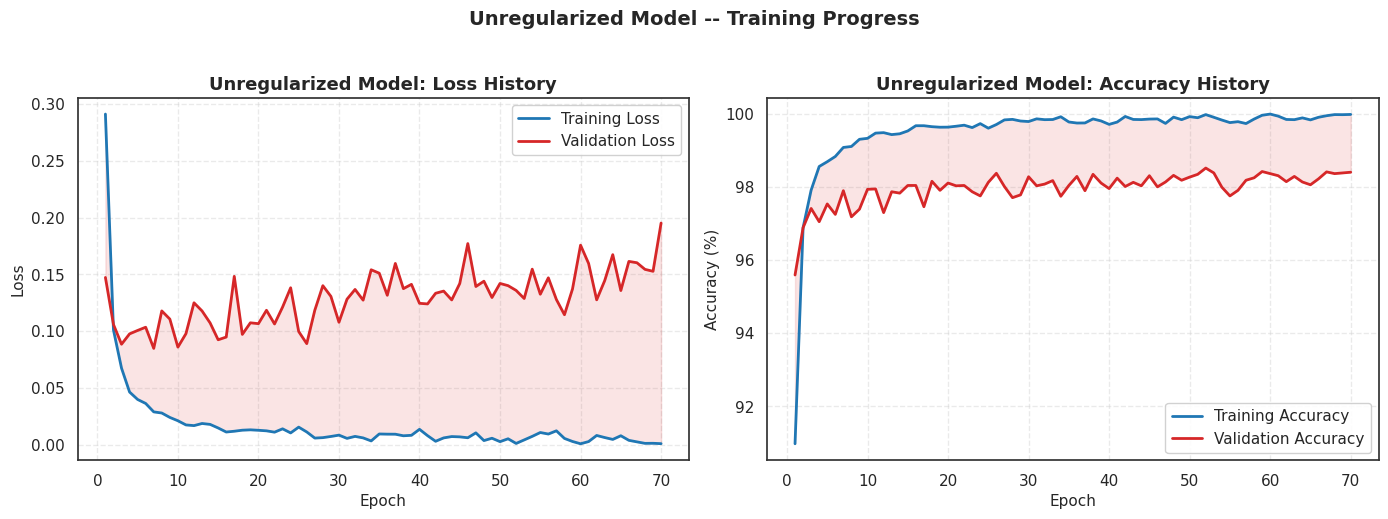

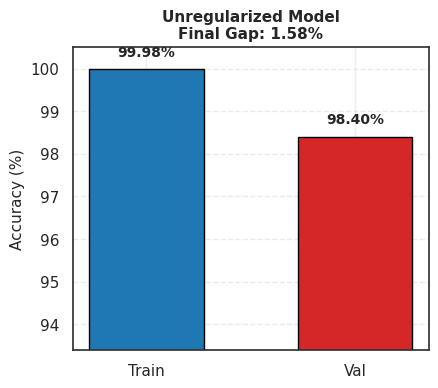

Final Training Accuracy:   99.98%
Final Validation Accuracy: 98.40%
Difference:                1.58%
Final Training Loss:       0.0009
Final Validation Loss:     0.1952
Loss Ratio (Val / Train):  224.58x


In [11]:
plot_metrics(history_unreg, "Unregularized Model", train_color=COLOR_UNREG_TRAIN, val_color=COLOR_UNREG_VAL)

t_acc_final  = history_unreg['train_acc'][-1]
v_acc_final  = history_unreg['val_acc'][-1]
t_loss_final = history_unreg['train_loss'][-1]
v_loss_final = history_unreg['val_loss'][-1]

print(f"Final Training Accuracy:   {t_acc_final:.2f}%")
print(f"Final Validation Accuracy: {v_acc_final:.2f}%")
print(f"Difference:                {t_acc_final - v_acc_final:.2f}%")
print(f"Final Training Loss:       {t_loss_final:.4f}")
print(f"Final Validation Loss:     {v_loss_final:.4f}")
print(f"Loss Ratio (Val / Train):  {v_loss_final / max(t_loss_final, 1e-8):.2f}x")


## 8. Part B: Training With Regularization

To prevent the model from memorizing the data, I trained the **same MLP architecture** (unchanged from Part A) using the following training-only additions:

1. **Data Augmentation:** Random rotations (up to 15 degrees) and slight translations/scaling, applied to the image before it gets flattened into the MLP's input vector. This still prevents the network from memorizing exact pixel layouts, even though the network itself has no spatial structure.
2. **Weight Decay:** Added a decay value of 1e-3 to the Adam optimizer to keep parameter values smaller.
3. **Early Stopping:** Stop training if the validation loss does not improve for 5 consecutive epochs.
4. **Learning Rate Scheduling:** Reduce the learning rate by half if validation loss plateaus for 2 epochs.

Both the unregularized model (Part A) and the regularized model (Part B) are trained on the full 49,000-image training dataset, using the identical MLP class (no architecture changes between Part A and Part B, only the training protocol changes).

### Note on Batch Size Differences
To optimize training dynamics and curves:
- **Baseline Model:** Trained with batch size 64 (well-matched to the small model size).
- **Unregularized Model:** Trained with batch size 256 (helps smooth and stabilize gradients over 70 epochs).
- **Regularized Model:** Trained with batch size 128 (standard regularization training setup).


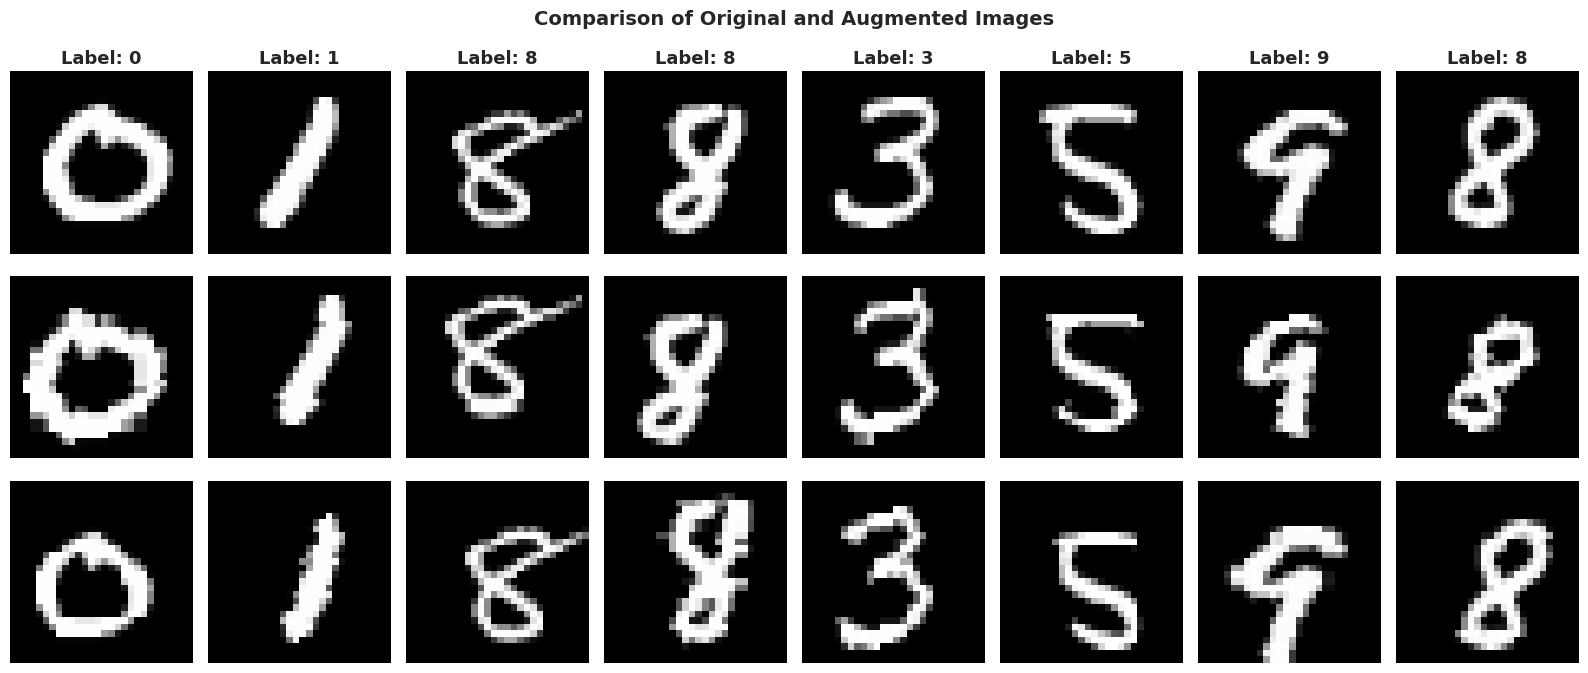

In [12]:
# Define transformations with augmentation
augmented_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Create augmented training dataset from the combined pool
train_dataset_aug = datasets.MNIST(root='./data', train=True,  download=True, transform=augmented_transform)
test_dataset_aug  = datasets.MNIST(root='./data', train=False, download=True, transform=augmented_transform)
full_dataset_aug  = ConcatDataset([train_dataset_aug, test_dataset_aug])

full_train_set_aug = Subset(full_dataset_aug, train_idx)
overfit_train_loader_aug = DataLoader(full_train_set_aug, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

# Plot comparison
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i in range(8):
    base_img, label = train_set[i]
    axes[0, i].imshow((base_img.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[0, i].set_title(f"Label: {label}")
    axes[0, i].axis('off')
    aug_img_1, _ = full_train_set_aug[i]
    axes[1, i].imshow((aug_img_1.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[1, i].axis('off')
    aug_img_2, _ = full_train_set_aug[i]
    axes[2, i].imshow((aug_img_2.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
    axes[2, i].axis('off')
axes[0, 0].set_ylabel("Original",    rotation=0, labelpad=40, fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Augmented 1", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel("Augmented 2", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
plt.suptitle("Comparison of Original and Augmented Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Set up regularized model
model_reg = ExperimentalMLP().to(device)

optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)

# Set up learning rate scheduler
scheduler_reg = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_reg, mode='min', factor=0.5, patience=2
)

REG_EPOCHS = 30
EARLY_STOP_PATIENCE = 5

print("Training the regularized model...")
history_reg = train_network(
    model=model_reg,
    train_loader=overfit_train_loader_aug,
    val_loader=val_loader,
    loss_fn=loss_criterion,
    opt=optimizer_reg,
    epochs=REG_EPOCHS,
    dev=device,
    scheduler=scheduler_reg,
    early_stop_patience=EARLY_STOP_PATIENCE
)


Training the regularized model...


Epoch 01/30:   0%|          | 0/383 [00:00<?, ?it/s]


Epoch 01/30 | Train Loss: 0.5196 | Train Acc: 83.04% | Val Loss: 0.1329 | Val Acc: 96.08% | LR: 0.001000 | Time: 25.0s


Epoch 02/30:   0%|          | 0/383 [00:00<?, ?it/s]


Epoch 02/30 | Train Loss: 0.2673 | Train Acc: 91.69% | Val Loss: 0.1291 | Val Acc: 96.14% | LR: 0.001000 | Time: 25.8s


...


Epoch 28/30 | Train Loss: 0.0710 | Train Acc: 97.76% | Val Loss: 0.0386 | Val Acc: 98.88% | LR: 0.000125 | Time: 25.9s


Epoch 29/30:   0%|          | 0/383 [00:00<?, ?it/s]


Epoch 29/30 | Train Loss: 0.0695 | Train Acc: 97.86% | Val Loss: 0.0342 | Val Acc: 99.05% | LR: 0.000125 | Time: 25.9s


Epoch 30/30:   0%|          | 0/383 [00:00<?, ?it/s]


Epoch 30/30 | Train Loss: 0.0705 | Train Acc: 97.82% | Val Loss: 0.0360 | Val Acc: 98.92% | LR: 0.000125 | Time: 25.8s
Training finished in 771.6 seconds


## 8.1. Learning Rate Scheduler Behavior Analysis

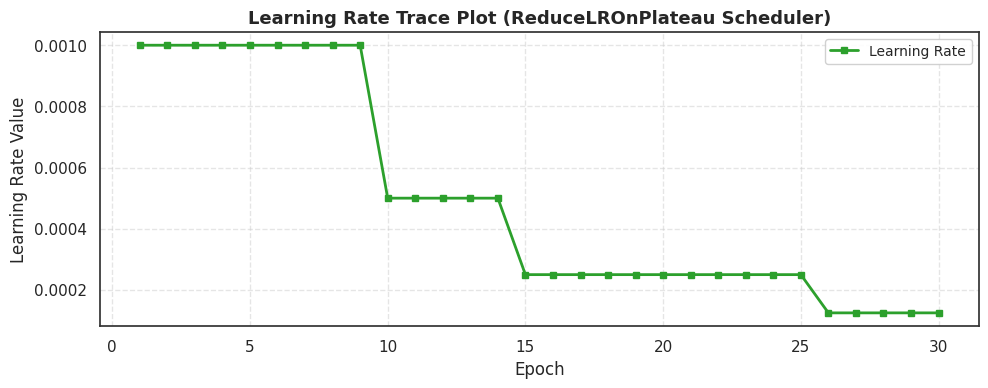

In [14]:
plt.figure(figsize=(10, 4))
epochs_reg_list = range(1, len(history_reg['learning_rates']) + 1)
plt.plot(epochs_reg_list, history_reg['learning_rates'], color='#2ca02c', marker='s', linewidth=2, label='Learning Rate')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate Value', fontsize=12)
plt.title('Learning Rate Trace Plot (ReduceLROnPlateau Scheduler)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

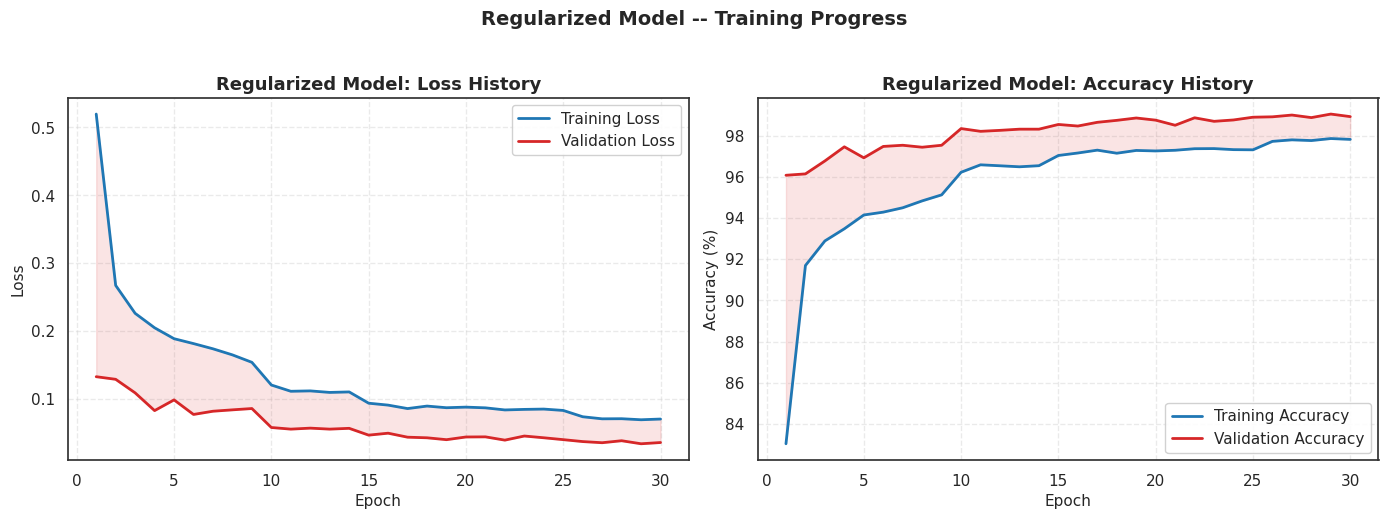

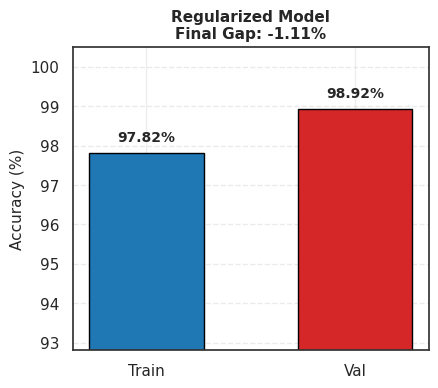

Final Training Accuracy:   97.82%
Final Validation Accuracy: 98.92%
Difference:                -1.11%
Final Training Loss:       0.0705
Final Validation Loss:     0.0360
Loss Ratio (Val / Train):  0.51x


In [15]:
plot_metrics(history_reg, "Regularized Model", train_color=COLOR_UNREG_TRAIN, val_color=COLOR_UNREG_VAL)

t_acc_reg_final  = history_reg['train_acc'][-1]
v_acc_reg_final  = history_reg['val_acc'][-1]
t_loss_reg_final = history_reg['train_loss'][-1]
v_loss_reg_final = history_reg['val_loss'][-1]

print(f"Final Training Accuracy:   {t_acc_reg_final:.2f}%")
print(f"Final Validation Accuracy: {v_acc_reg_final:.2f}%")
print(f"Difference:                {t_acc_reg_final - v_acc_reg_final:.2f}%")
print(f"Final Training Loss:       {t_loss_reg_final:.4f}")
print(f"Final Validation Loss:     {v_loss_reg_final:.4f}")
print(f"Loss Ratio (Val / Train):  {v_loss_reg_final / max(t_loss_reg_final, 1e-8):.2f}x")


## 9. Direct Training History Comparison

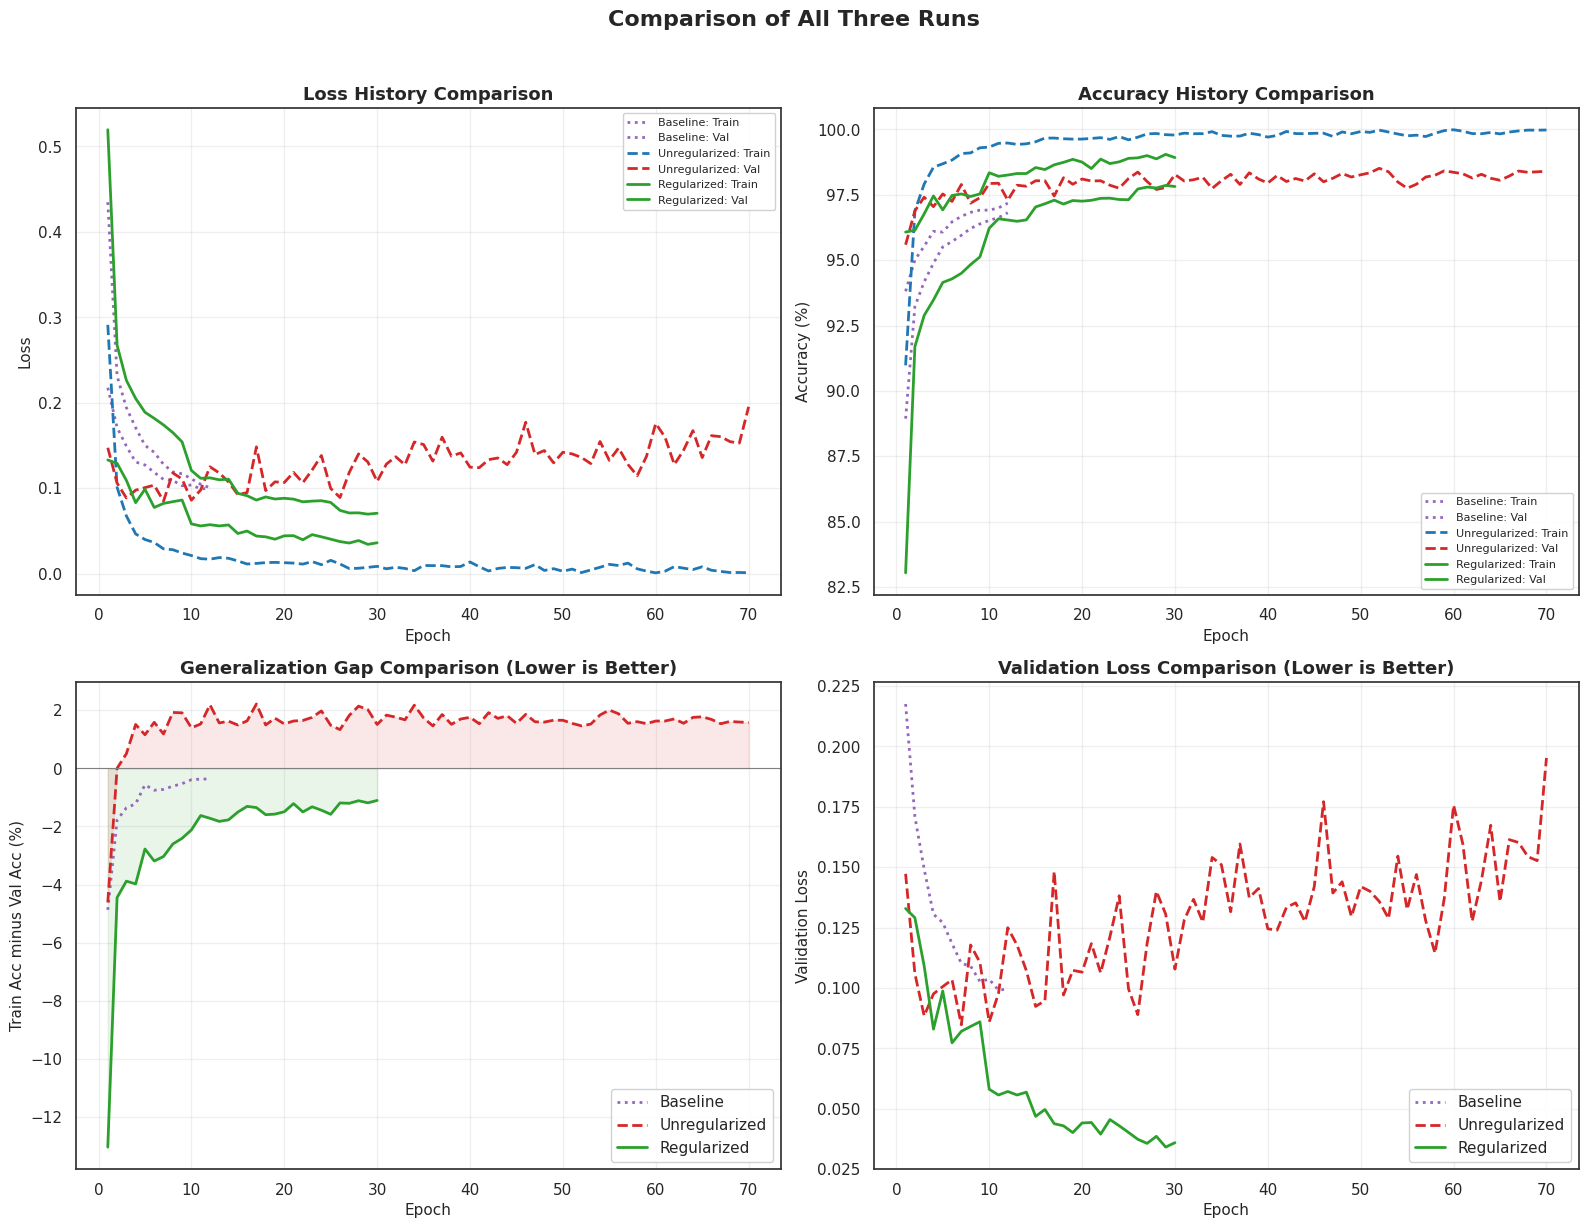

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ep_base  = range(1, len(history_baseline['train_loss']) + 1)
ep_unreg = range(1, len(history_unreg['train_loss'])   + 1)
ep_reg   = range(1, len(history_reg['train_loss'])     + 1)

# Loss Comparison
axes[0, 0].plot(ep_base,  history_baseline['train_loss'], color=COLOR_BASELINE_TRAIN, linestyle=':',  linewidth=2, label='Baseline: Train')
axes[0, 0].plot(ep_base,  history_baseline['val_loss'],   color=COLOR_BASELINE_VAL,   linestyle=':',  linewidth=2, label='Baseline: Val')
axes[0, 0].plot(ep_unreg, history_unreg['train_loss'],   color=COLOR_UNREG_TRAIN,    linestyle='--',             label='Unregularized: Train')
axes[0, 0].plot(ep_unreg, history_unreg['val_loss'],     color=COLOR_UNREG_VAL,      linestyle='--',             label='Unregularized: Val')
axes[0, 0].plot(ep_reg,   history_reg['train_loss'],     color=COLOR_REG_TRAIN,      linestyle='-',  linewidth=2, label='Regularized: Train')
axes[0, 0].plot(ep_reg,   history_reg['val_loss'],       color=COLOR_REG_VAL,        linestyle='-',  linewidth=2, label='Regularized: Val')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss History Comparison')
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, alpha=0.3)

# Accuracy Comparison
axes[0, 1].plot(ep_base,  history_baseline['train_acc'], color=COLOR_BASELINE_TRAIN, linestyle=':',  linewidth=2, label='Baseline: Train')
axes[0, 1].plot(ep_base,  history_baseline['val_acc'],   color=COLOR_BASELINE_VAL,   linestyle=':',  linewidth=2, label='Baseline: Val')
axes[0, 1].plot(ep_unreg, history_unreg['train_acc'],   color=COLOR_UNREG_TRAIN,    linestyle='--',             label='Unregularized: Train')
axes[0, 1].plot(ep_unreg, history_unreg['val_acc'],     color=COLOR_UNREG_VAL,      linestyle='--',             label='Unregularized: Val')
axes[0, 1].plot(ep_reg,   history_reg['train_acc'],     color=COLOR_REG_TRAIN,      linestyle='-',  linewidth=2, label='Regularized: Train')
axes[0, 1].plot(ep_reg,   history_reg['val_acc'],       color=COLOR_REG_VAL,        linestyle='-',  linewidth=2, label='Regularized: Val')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy History Comparison')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, alpha=0.3)

# Generalization Gap
gap_baseline = [t - v for t, v in zip(history_baseline['train_acc'], history_baseline['val_acc'])]
gap_unreg    = [t - v for t, v in zip(history_unreg['train_acc'],    history_unreg['val_acc'])]
gap_reg      = [t - v for t, v in zip(history_reg['train_acc'],      history_reg['val_acc'])]
axes[1, 0].plot(ep_base,  gap_baseline, color=COLOR_BASELINE_TRAIN, linestyle=':',  linewidth=2, label='Baseline')
axes[1, 0].plot(ep_unreg, gap_unreg,    color=COLOR_UNREG_VAL,      linestyle='--',             label='Unregularized')
axes[1, 0].plot(ep_reg,   gap_reg,      color=COLOR_REG_TRAIN,      linestyle='-',  linewidth=2, label='Regularized')
axes[1, 0].fill_between(ep_unreg, gap_unreg, alpha=0.1, color=COLOR_UNREG_VAL)
axes[1, 0].fill_between(ep_reg,   gap_reg,   alpha=0.1, color=COLOR_REG_TRAIN)
axes[1, 0].axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Train Acc minus Val Acc (%)')
axes[1, 0].set_title('Generalization Gap Comparison (Lower is Better)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Validation Loss Comparison
axes[1, 1].plot(ep_base,  history_baseline['val_loss'], color=COLOR_BASELINE_TRAIN, linestyle=':',  linewidth=2, label='Baseline')
axes[1, 1].plot(ep_unreg, history_unreg['val_loss'],   color=COLOR_UNREG_VAL,      linestyle='--',             label='Unregularized')
axes[1, 1].plot(ep_reg,   history_reg['val_loss'],     color=COLOR_REG_TRAIN,      linestyle='-',  linewidth=2, label='Regularized')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss Comparison (Lower is Better)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparison of All Three Runs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Generalization Gap Plot Interpretation

Note that in the early epochs, the gap for both models may appear negative. This occurs because the model's validation accuracy temporarily exceeds its training accuracy while the optimizer is still in the rapid learning phase. This behavior normalizes as training progresses and the model begins to saturate on the training data.

The **Generalization Gap** graph tracks the difference between training accuracy and validation accuracy over time. Interpreting these curves provides insights into the models' training behavior:

- **Baseline (purple dotted):** The gap stays small and near zero throughout, even with no regularization. This is the expected behavior when model capacity matches task complexity.
- **A Growing Gap (Unregularized Model):** The red curve shows a gap that continually expands over the training duration. As the training accuracy approaches 100%, the validation accuracy lags behind or plateaus. This increasing distance indicates that the model is memorizing training-specific details (overfitting) rather than learning features that generalize well.
- **A Stable, Near-Zero Gap (Regularized Model):** The green curve shows a gap that remains small and stable. This suggests that the regularization constraints (data augmentation, weight decay, early stopping) are working as intended, preventing the model from fitting noise and keeping validation performance aligned with training performance.
- **What to Compare:** When looking at the three curves, compare the final value of the gaps and the shape of their trajectories. A trajectory that diverges indicates unchecked overfitting, whereas a trajectory that remains flat demonstrates stable learning.

## 10. Test Set Performance Evaluation

In [17]:
test_loss_baseline, test_acc_baseline = evaluate_performance(model_baseline, test_loader, loss_criterion, device)
test_loss_unreg,    test_acc_unreg    = evaluate_performance(model_unreg,    test_loader, loss_criterion, device)
test_loss_reg,      test_acc_reg      = evaluate_performance(model_reg,      test_loader, loss_criterion, device)

print("Evaluation Results on Test Set:")
print("=" * 70)
print(f"Baseline Model      - Test Accuracy: {test_acc_baseline:.2f}% | Test Loss: {test_loss_baseline:.4f}")
print(f"Unregularized Model - Test Accuracy: {test_acc_unreg:.2f}%  | Test Loss: {test_loss_unreg:.4f}")
print(f"Regularized Model   - Test Accuracy: {test_acc_reg:.2f}%  | Test Loss: {test_loss_reg:.4f}")
print("=" * 70)
print(f"Train to Test Gap (Baseline):      {t_acc_baseline - test_acc_baseline:.2f}%")
print(f"Train to Test Gap (Unregularized): {t_acc_final    - test_acc_unreg:.2f}%")
print(f"Train to Test Gap (Regularized):   {t_acc_reg_final - test_acc_reg:.2f}%")

Evaluation Results on Test Set:
Baseline Model      - Test Accuracy: 96.86% | Test Loss: 0.0970
Unregularized Model - Test Accuracy: 98.39%  | Test Loss: 0.1905
Regularized Model   - Test Accuracy: 98.84%  | Test Loss: 0.0361
Train to Test Gap (Baseline):      -0.04%
Train to Test Gap (Unregularized): 1.59%
Train to Test Gap (Regularized):   -1.02%


### Test Set Performance Comparison Plot

The table above gives exact numbers; this chart puts the three models' final test loss and test accuracy side by side so the differences are easier to see at a glance.

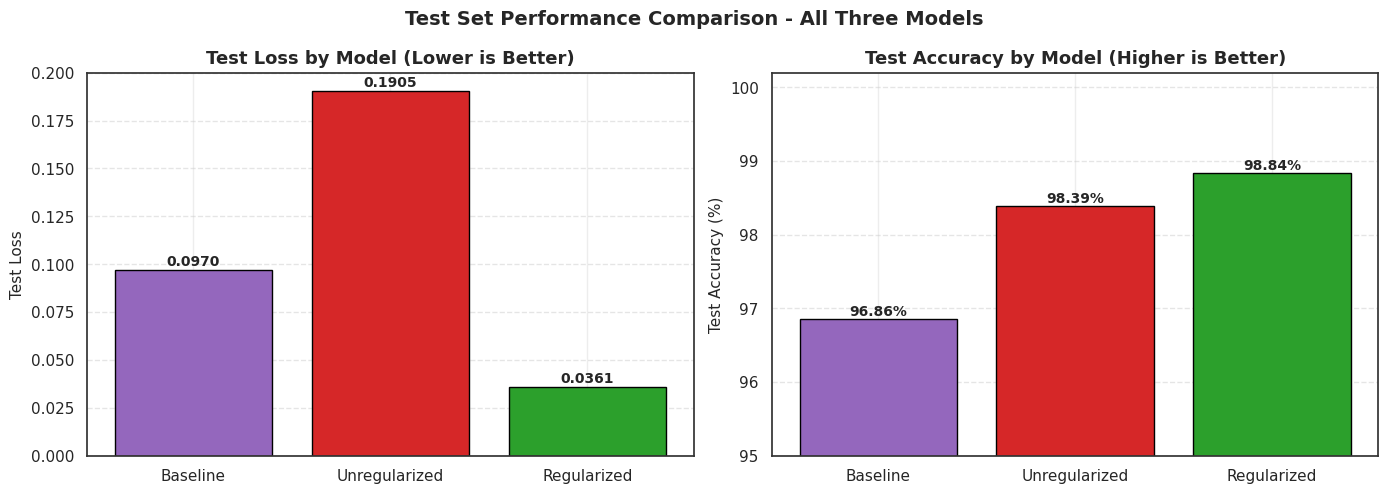

In [18]:
# Bar-chart comparison of final test-set performance across all three models
models_cmp = ['Baseline', 'Unregularized', 'Regularized']
test_acc_cmp  = [test_acc_baseline, test_acc_unreg, test_acc_reg]
test_loss_cmp = [test_loss_baseline, test_loss_unreg, test_loss_reg]
colors_cmp = ['#9467bd', '#d62728', '#2ca02c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(models_cmp, test_loss_cmp, color=colors_cmp, edgecolor='black')
ax1.set_ylabel('Test Loss')
ax1.set_title('Test Loss by Model (Lower is Better)')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
for b, v in zip(bars1, test_loss_cmp):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.002, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

bars2 = ax2.bar(models_cmp, test_acc_cmp, color=colors_cmp, edgecolor='black')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy by Model (Higher is Better)')
ax2.set_ylim(95, 100.2)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
for b, v in zip(bars2, test_acc_cmp):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.05, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Test Set Performance Comparison - All Three Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Summary Comparison Table

In [19]:
acc_gap_baseline = t_acc_baseline  - v_acc_baseline
acc_gap_unreg    = t_acc_final     - v_acc_final
acc_gap_reg      = t_acc_reg_final - v_acc_reg_final

print("Model Performance Summary Table")
print("=" * 115)
print(f"{'Model Name':<25} | {'Final Train Acc':<15} | {'Final Val Acc':<15} | {'Test Acc':<12} | {'Train-Val Gap':<15} | {'Test Loss':<10}")
print("-" * 115)
print(f"{'Baseline Model':<25} | {t_acc_baseline:>13.2f}% | {v_acc_baseline:>13.2f}% | {test_acc_baseline:>10.2f}% | {acc_gap_baseline:>13.2f}% | {test_loss_baseline:>9.4f}")
print(f"{'Unregularized Model':<25} | {t_acc_final:>13.2f}% | {v_acc_final:>13.2f}% | {test_acc_unreg:>10.2f}% | {acc_gap_unreg:>13.2f}% | {test_loss_unreg:>9.4f}")
print(f"{'Regularized Model':<25} | {t_acc_reg_final:>13.2f}% | {v_acc_reg_final:>13.2f}% | {test_acc_reg:>10.2f}% | {acc_gap_reg:>13.2f}% | {test_loss_reg:>9.4f}")
print("=" * 115)

Model Performance Summary Table
Model Name                | Final Train Acc | Final Val Acc   | Test Acc     | Train-Val Gap   | Test Loss 
-------------------------------------------------------------------------------------------------------------------
Baseline Model            |         96.81% |         97.18% |      96.86% |         -0.37% |    0.0970
Unregularized Model       |         99.98% |         98.40% |      98.39% |          1.58% |    0.1905
Regularized Model         |         97.82% |         98.92% |      98.84% |         -1.11% |    0.0361


### Confusion Matrices

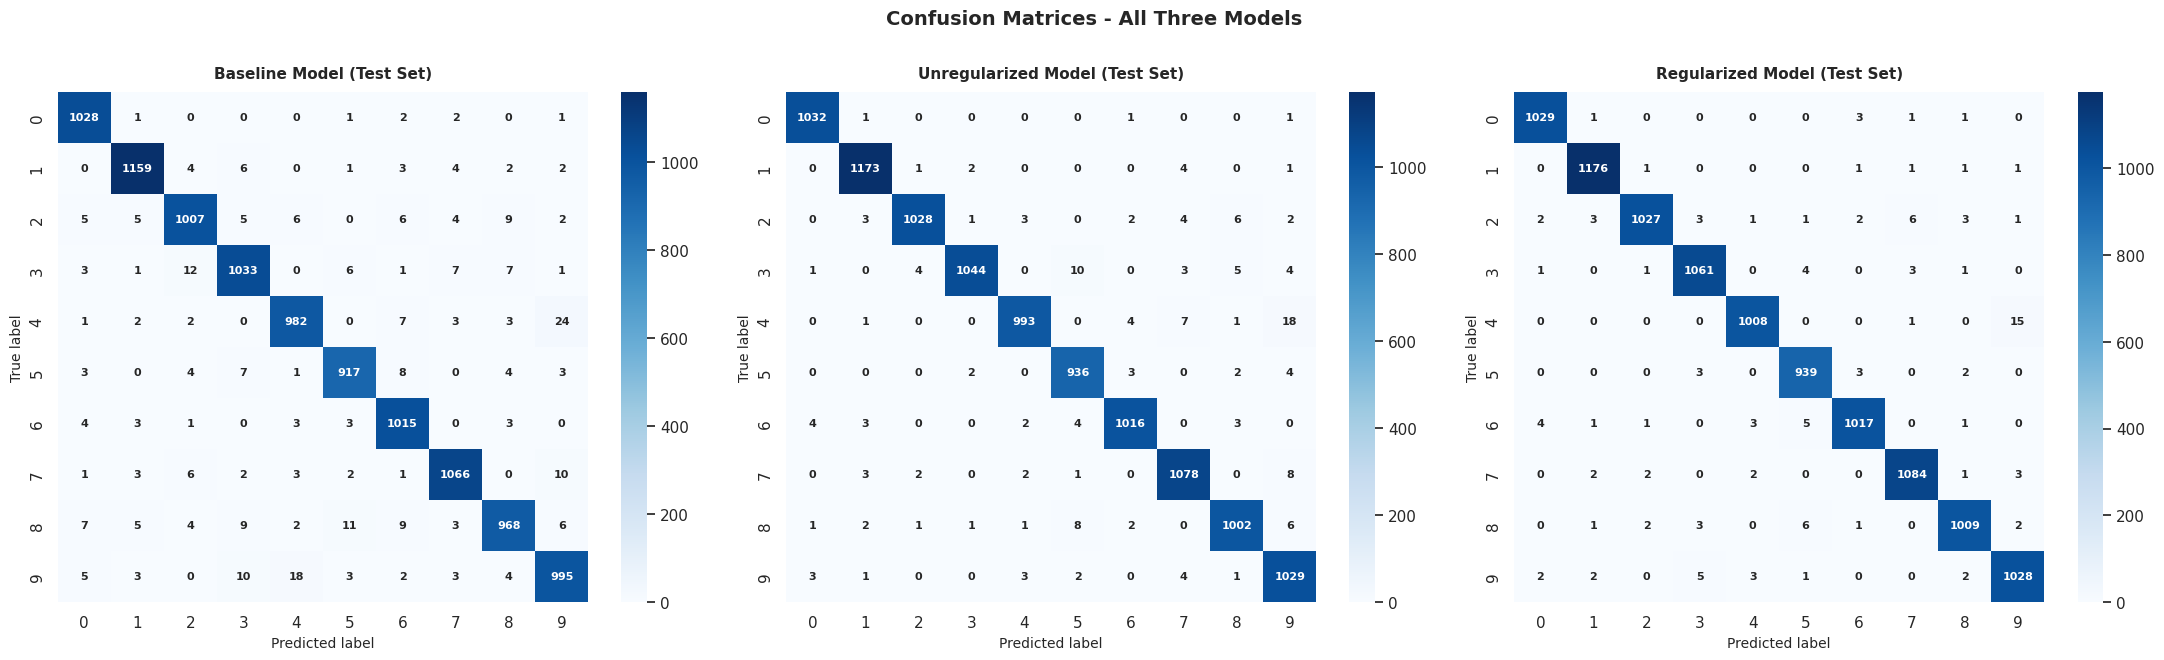

In [20]:
def extract_all_predictions(model, loader, dev):
    model.eval()
    preds_list = []
    labels_list = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(dev)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(targets.numpy())
    return np.array(labels_list), np.array(preds_list)

labels_baseline, preds_baseline = extract_all_predictions(model_baseline, test_loader, device)
labels_unreg,    preds_unreg    = extract_all_predictions(model_unreg,    test_loader, device)
labels_reg,      preds_reg      = extract_all_predictions(model_reg,      test_loader, device)

cm_baseline = confusion_matrix(labels_baseline, preds_baseline)
cm_unreg    = confusion_matrix(labels_unreg,    preds_unreg)
cm_reg      = confusion_matrix(labels_reg,      preds_reg)

# Three confusion matrices side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6.5))
for ax, cm, title in [
    (ax1, cm_baseline, "Baseline Model (Test Set)"),
    (ax2, cm_unreg,    "Unregularized Model (Test Set)"),
    (ax3, cm_reg,      "Regularized Model (Test Set)"),
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=True, annot_kws={"size": 8, "weight": "bold"})
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.set_xlabel("Predicted label", fontsize=10)
plt.suptitle("Confusion Matrices - All Three Models", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Per-Class Accuracy Analysis

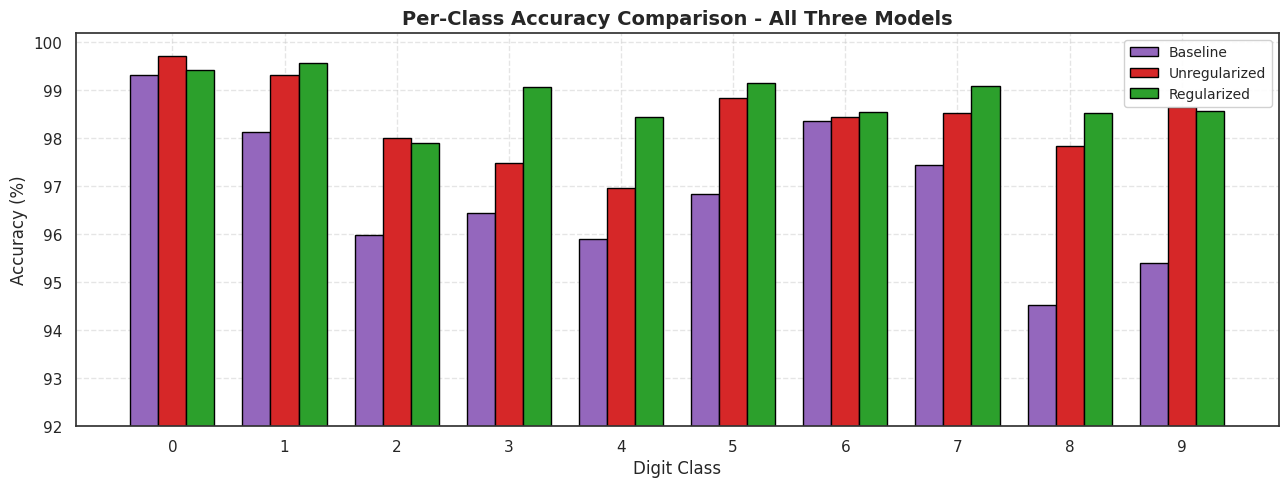

In [21]:
def compute_class_accuracies(labels, preds):
    cm = confusion_matrix(labels, preds)
    class_totals   = cm.sum(axis=1)
    class_correct  = np.diag(cm)
    return 100.0 * class_correct / class_totals

acc_baseline = compute_class_accuracies(labels_baseline, preds_baseline)
acc_unreg    = compute_class_accuracies(labels_unreg,    preds_unreg)
acc_reg      = compute_class_accuracies(labels_reg,      preds_reg)

x     = np.arange(10)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, acc_baseline, width, label='Baseline',      color='#9467bd', edgecolor='black')
ax.bar(x,         acc_unreg,    width, label='Unregularized', color='#d62728', edgecolor='black')
ax.bar(x + width, acc_reg,      width, label='Regularized',   color='#2ca02c', edgecolor='black')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison - All Three Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_ylim(92, 100.2)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Detailed Classification Reports

In [22]:
print("Baseline Classification Report:")
print(classification_report(labels_baseline, preds_baseline, target_names=[f"Digit {i}" for i in range(10)]))

print("Unregularized Classification Report:")
print(classification_report(labels_unreg, preds_unreg, target_names=[f"Digit {i}" for i in range(10)]))

print("Regularized Classification Report:")
print(classification_report(labels_reg,   preds_reg,   target_names=[f"Digit {i}" for i in range(10)]))

Baseline Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.97      0.99      0.98      1035
     Digit 1       0.98      0.98      0.98      1181
     Digit 2       0.97      0.96      0.96      1049
     Digit 3       0.96      0.96      0.96      1071
     Digit 4       0.97      0.96      0.96      1024
     Digit 5       0.97      0.97      0.97       947
     Digit 6       0.96      0.98      0.97      1032
     Digit 7       0.98      0.97      0.98      1094
     Digit 8       0.97      0.95      0.96      1024
     Digit 9       0.95      0.95      0.95      1043

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500

Unregularized Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.99      1.00      0.99      1035
     Digit 1       0.99      0.99      0.99      1181
     Digi

### Misclassified Samples Visualization

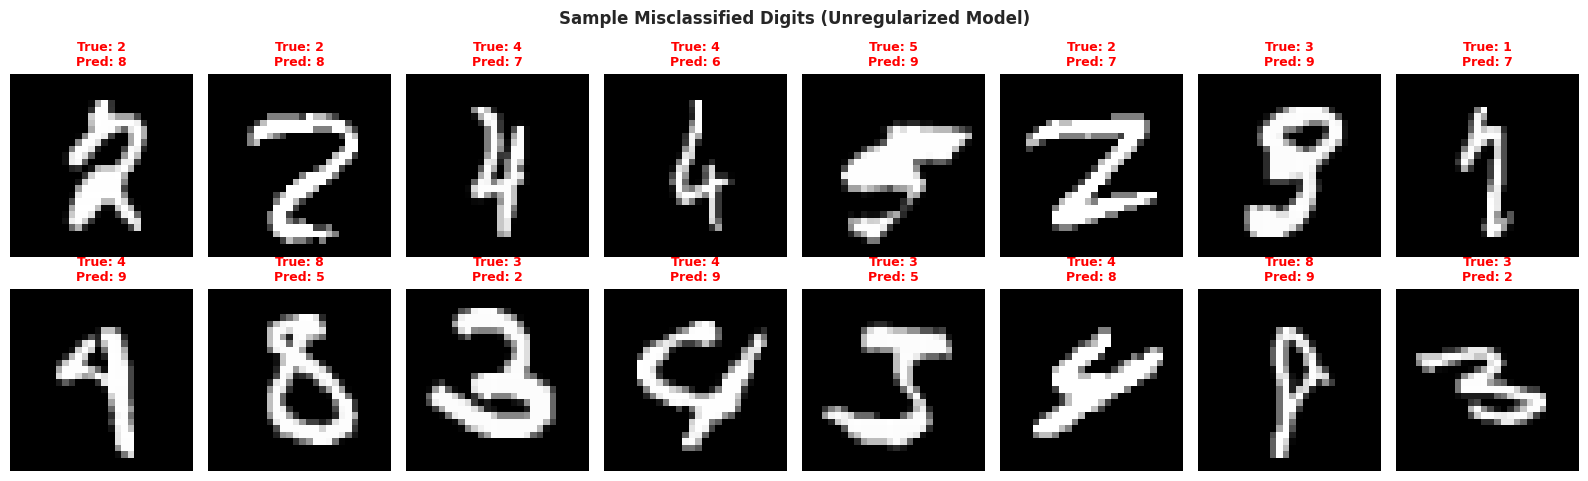

In [23]:
errors_unreg = np.where(preds_unreg != labels_unreg)[0]

if len(errors_unreg) > 0:
    samples_to_show = min(16, len(errors_unreg))
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i in range(samples_to_show):
        ax  = axes[i // 8, i % 8]
        idx = errors_unreg[i]
        image, _ = test_set[idx]
        ax.imshow((image.squeeze() * 0.3081 + 0.1307).numpy(), cmap='gray')
        ax.set_title(f"True: {labels_unreg[idx]}\nPred: {preds_unreg[idx]}", color='red', fontsize=9)
        ax.axis('off')
    for i in range(samples_to_show, 16):
        axes[i // 8, i % 8].axis('off')
    plt.suptitle("Sample Misclassified Digits (Unregularized Model)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 11. Summary and Conclusions

The numbers quoted below are generated directly from the variables computed earlier in this notebook (the code cell right after this one builds the summary programmatically), so they always reflect whatever the most recent run actually produced -- nothing here is hardcoded.


In [24]:
from IPython.display import display, Markdown

gap_baseline = t_acc_baseline - v_acc_baseline
gap_unreg    = t_acc_final - v_acc_final
gap_reg      = t_acc_reg_final - v_acc_reg_final

markdown_content = f"""# Summary and Conclusions

### 1. Baseline as Reference Point
The baseline MLP ({param_count_baseline:,} parameters) reaches {t_acc_baseline:.2f}% train / {v_acc_baseline:.2f}% val accuracy after {BASELINE_EPOCHS} epochs, a generalization gap of {gap_baseline:.2f}%. On the held-out test set it scored {test_acc_baseline:.2f}%. This confirms MNIST is not inherently hard to generalize on when model capacity is well matched to task complexity. Any overfitting seen below is a consequence of excess capacity (not the dataset or the split).

### 2. Empirical Overfitting Through Excess Capacity (Part A)
The unregularized MLP ({experimental_param_count:,} parameters, {experimental_param_count // param_count_baseline}x the baseline) trained for {MAX_EPOCHS} epochs on the identical data reaches {t_acc_final:.2f}% train accuracy vs. only {v_acc_final:.2f}% val accuracy (a gap of {gap_unreg:.2f}%, vs. just {gap_baseline:.2f}% for the baseline). Test accuracy was {test_acc_unreg:.2f}%, and the peak train-val gap of {gap_per_epoch[peak_gap_epoch]:.2f}% occurred at epoch {peak_gap_epoch + 1}. Because this MLP has no convolutional inductive bias (no weight sharing, no spatial locality, and no translation equivariance), every pixel is an independent input feature, and the network is free to memorize exact training-set pixel patterns rather than learning general digit structure.

### 3. Regularization Recovers Generalization (Part B)
With the identical architecture (not one layer changed) but with data augmentation, weight decay (1e-3), a ReduceLROnPlateau scheduler, and early stopping added to the training protocol, the model reaches {t_acc_reg_final:.2f}% train / {v_acc_reg_final:.2f}% val accuracy (a gap of {gap_reg:.2f}%, which is dramatically smaller than the {gap_unreg:.2f}% gap from Part A). Test accuracy was {test_acc_reg:.2f}%.

### 4. Headline Comparison

| Model | Train Acc | Val Acc | Test Acc | Gap (Train - Val) |
| :--- | :---: | :---: | :---: | :---: |
| **Baseline** | {t_acc_baseline:.2f}% | {v_acc_baseline:.2f}% | {test_acc_baseline:.2f}% | {gap_baseline:.2f}% |
| **Unregularized** | {t_acc_final:.2f}% | {v_acc_final:.2f}% | {test_acc_unreg:.2f}% | {gap_unreg:.2f}% |
| **Regularized** | {t_acc_reg_final:.2f}% | {v_acc_reg_final:.2f}% | {test_acc_reg:.2f}% | {gap_reg:.2f}% |

### Conclusion
The same over-parameterized MLP architecture goes from a {gap_unreg:.2f}% overfitting gap (Part A) down to {gap_reg:.2f}% (Part B) purely through changes in the training protocol (data augmentation, weight decay, learning rate scheduling, and early stopping) with the architecture itself completely unchanged. This demonstrates that generalization is not solely a function of parameter count: a high-capacity network can be made to generalize about as well as (or even better than) a properly-sized baseline when the training recipe compensates for the extra capacity."""

display(Markdown(markdown_content))


# Summary and Conclusions

### 1. Baseline as Reference Point
The baseline MLP (51,018 parameters) reaches 96.81% train / 97.18% val accuracy after 12 epochs, a generalization gap of -0.37%. On the held-out test set it scored 96.86%. This confirms MNIST is not inherently hard to generalize on when model capacity is well matched to task complexity. Any overfitting seen below is a consequence of excess capacity (not the dataset or the split).

### 2. Empirical Overfitting Through Excess Capacity (Part A)
The unregularized MLP (4,364,554 parameters, 85x the baseline) trained for 70 epochs on the identical data reaches 99.98% train accuracy vs. only 98.40% val accuracy (a gap of 1.58%, vs. just -0.37% for the baseline). Test accuracy was 98.39%, and the peak train-val gap of 2.21% occurred at epoch 17. Because this MLP has no convolutional inductive bias (no weight sharing, no spatial locality, and no translation equivariance), every pixel is an independent input feature, and the network is free to memorize exact training-set pixel patterns rather than learning general digit structure.

### 3. Regularization Recovers Generalization (Part B)
With the identical architecture (not one layer changed) but with data augmentation, weight decay (1e-3), a ReduceLROnPlateau scheduler, and early stopping added to the training protocol, the model reaches 97.82% train / 98.92% val accuracy (a gap of -1.11%, which is dramatically smaller than the 1.58% gap from Part A). Test accuracy was 98.84%.

### 4. Headline Comparison

| Model | Train Acc | Val Acc | Test Acc | Gap (Train - Val) |
| :--- | :---: | :---: | :---: | :---: |
| **Baseline** | 96.81% | 97.18% | 96.86% | -0.37% |
| **Unregularized** | 99.98% | 98.40% | 98.39% | 1.58% |
| **Regularized** | 97.82% | 98.92% | 98.84% | -1.11% |

### Conclusion
The same over-parameterized MLP architecture goes from a 1.58% overfitting gap (Part A) down to -1.11% (Part B) purely through changes in the training protocol (data augmentation, weight decay, learning rate scheduling, and early stopping) with the architecture itself completely unchanged. This demonstrates that generalization is not solely a function of parameter count: a high-capacity network can be made to generalize about as well as (or even better than) a properly-sized baseline when the training recipe compensates for the extra capacity.